<a class="anchor" id="0">

# **0. Setup & Imports**

[Back to TOC](#toc)
</a>


In [10]:
%pip install wordcloud nltk  

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter
import warnings
import nltk

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
LABEL_MAP  = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
PALETTE    = {0: '#E24B4A', 1: '#1D9E75', 2: '#378ADD'}
STOP_WORDS = set(stopwords.words('english'))

<a class="anchor" id="1">

# **1. Load Data**

[Back to TOC](#toc)
</a>


In [12]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()

#Check basic info about the dataset

print(train.info())
print('\nMissing values:\n', train.isnull().sum())
print('\nDuplicate tweets:', train.duplicated(subset='text').sum())

Train shape: (9543, 2)
Test shape : (2388, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB
None

Missing values:
 text     0
label    0
dtype: int64

Duplicate tweets: 0


<a class="anchor" id="2">

## **2. Data Exploration**

[Back to TOC](#toc)
</a>

As we can see, the dataset contains 7613 training samples and 3263 test samples. Each sample consists of a tweet (text) and a label indicating wether the tweet is bearish (0) or bullish (1), or neutral (2). There are no missing values in the dataset nor duplicate tweets, which is a good initial sign for data quality.

<a class="anchor" id="2_1">

## **2.1 Class Distribution**

[Back to TOC](#toc)
</a>

Now let's check the distribution of the classes in the training set to see if we have any imbalance issues.

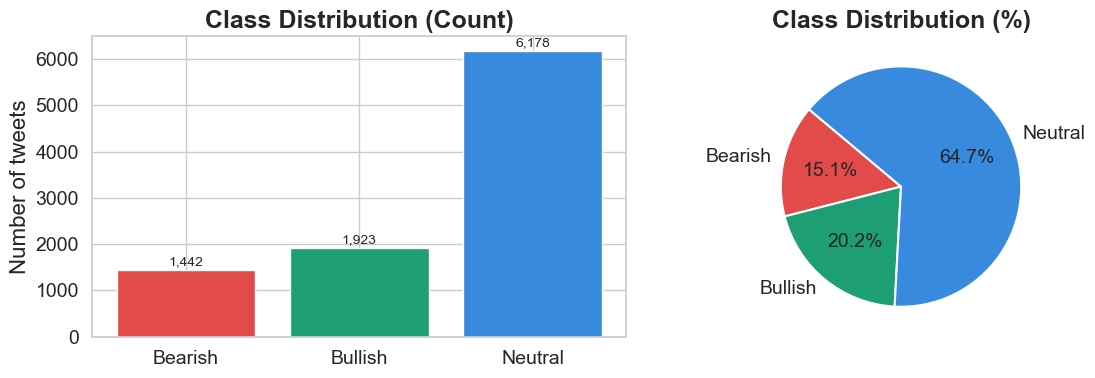

In [13]:

plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.labelsize': 16,      # X/Y label size
    'axes.titlesize': 18,      # Subplot title size
    'xtick.labelsize': 14,     # X-axis tick labels
    'ytick.labelsize': 14,     # Y-axis tick labels
    'legend.fontsize': 14,     # Legend text size
    'legend.title_fontsize': 16
})

counts = train['label'].value_counts().sort_index()
counts.index = [LABEL_MAP[i] for i in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[i] for i in sorted(PALETTE)],
                   edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of tweets')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=10)

axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[i] for i in sorted(PALETTE)],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_2">

## **2.2 Tweet Length**

[Back to TOC](#toc)
</a>

Next, let's analyze the length of the tweets in terms of number of characters and words to understand the typical tweet structure in our dataset.

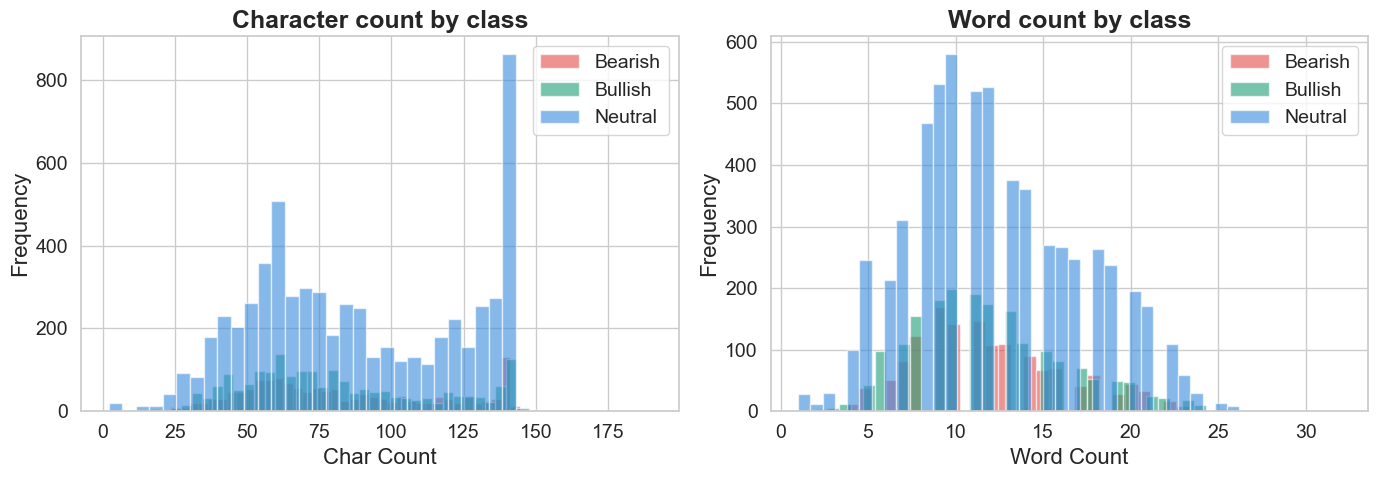

In [14]:
train['char_count'] = train['text'].str.len()
train['word_count'] = train['text'].str.split().str.len()
train['label_name'] = train['label'].map(LABEL_MAP)

# Your existing code (histograms)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax, title in [
    ('char_count', axes[0], 'Character count by class'),
    ('word_count', axes[1], 'Word count by class')
]:
    for lid, lname in LABEL_MAP.items():
        ax.hist(train[train['label']==lid][metric],
                bins=40, alpha=0.6, label=lname, color=PALETTE[lid])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric.replace('_',' ').title())
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('length_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# # Boxplots (text will inherit rcParams, but you can also enlarge more)
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# sns.boxplot(data=train, x='label_name', y='char_count', order=order, palette=pal, ax=axes[0])
# axes[0].set_title('Character Count per Class', fontweight='bold', fontsize=18)  # explicit size
# axes[0].set_xlabel('', fontsize=16)
# axes[0].set_ylabel('Character Count', fontsize=16)
# axes[0].tick_params(axis='both', labelsize=14)

# sns.boxplot(data=train, x='label_name', y='word_count', order=order, palette=pal, ax=axes[1])
# axes[1].set_title('Word Count per Class', fontweight='bold', fontsize=18)
# axes[1].set_xlabel('', fontsize=16)
# axes[1].set_ylabel('Word Count', fontsize=16)
# axes[1].tick_params(axis='both', labelsize=14)

# plt.tight_layout()
# plt.savefig('length_boxplots.png', dpi=150, bbox_inches='tight')
# plt.show()

<a class="anchor" id="2_3">

## **2.3 Top Tokens per Class**

[Back to TOC](#toc)
</a>

Next, let's look at the most common words used in each class to get a sense of the language patterns associated with bullish, bearish, and neutral tweets.

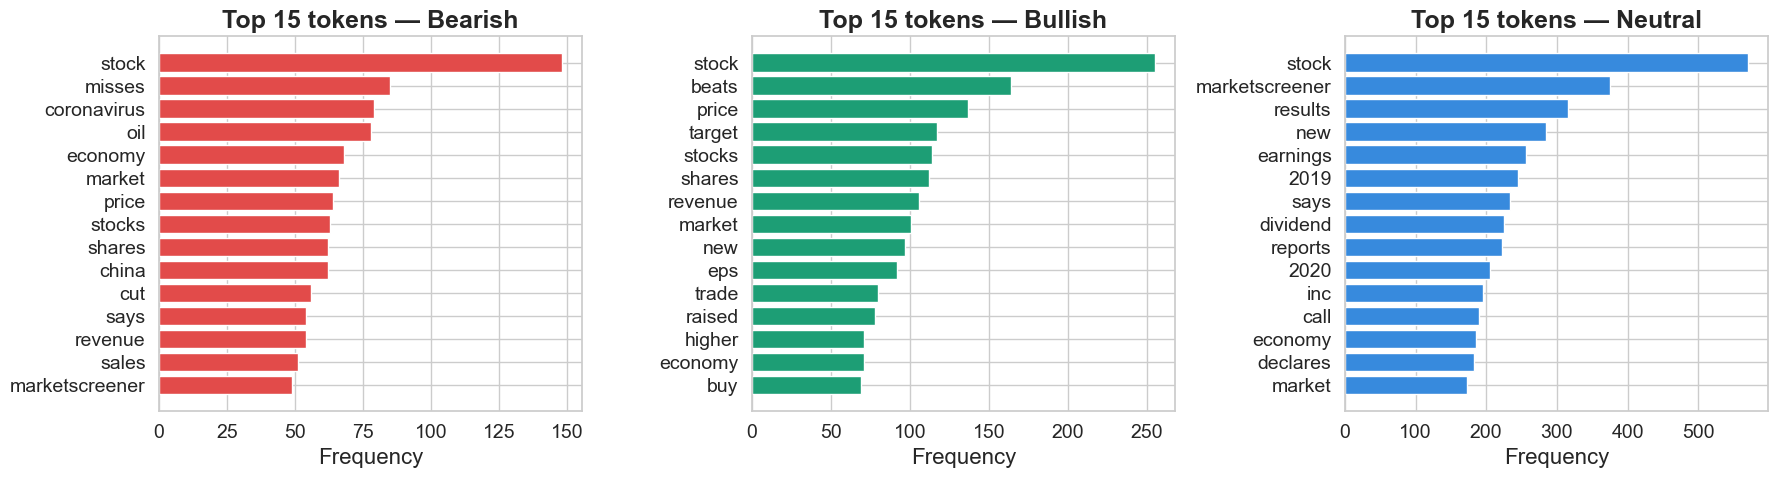

In [15]:
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = [t for t in text.split()
              if t not in STOP_WORDS and len(t) > 2]
    return tokens

train['tokens'] = train['text'].apply(basic_clean)

TOP_N = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label_id, ax in zip(sorted(LABEL_MAP), axes):
    all_tokens = [tok for toks in train[train['label']==label_id]['tokens'] for tok in toks]
    words, freqs = zip(*Counter(all_tokens).most_common(TOP_N))
    ax.barh(list(words)[::-1], list(freqs)[::-1], color=PALETTE[label_id], edgecolor='white')
    ax.set_title(f'Top {TOP_N} tokens — {LABEL_MAP[label_id]}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_tokens_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_4">

## **2.4 Word Clouds**

[Back to TOC](#toc)
</a>

Next, let's visualize the most common words in each class using word clouds to get a more intuitive understanding of the language used in bullish, bearish, and neutral tweets.

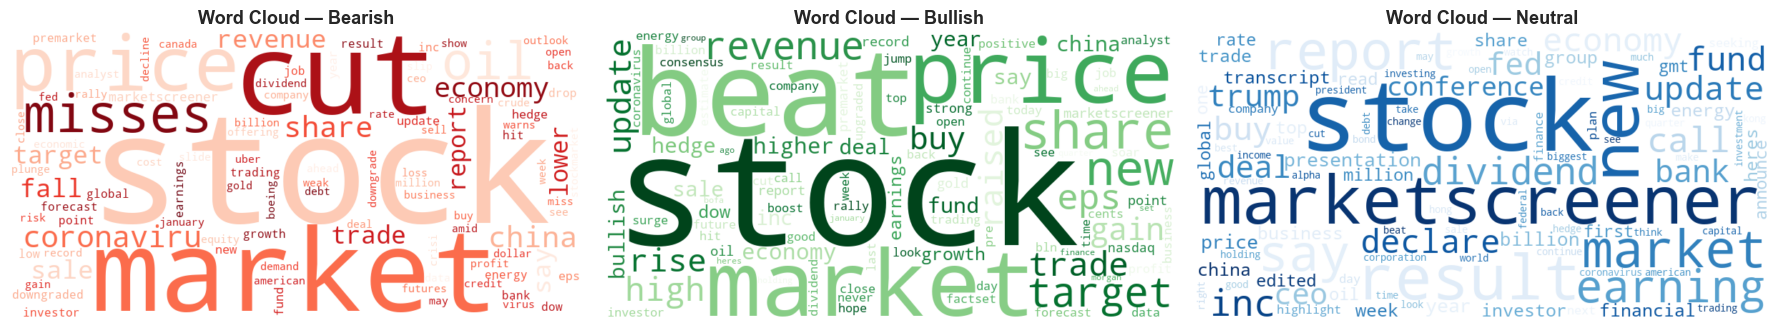

In [16]:
cmaps = {0: 'Reds', 1: 'Greens', 2: 'Blues'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for label_id, ax in zip(sorted(LABEL_MAP), axes):
    corpus = ' '.join(tok for toks in train[train['label']==label_id]['tokens'] for tok in toks)
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap=cmaps[label_id],
                   max_words=100,
                   collocations=False).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {LABEL_MAP[label_id]}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_5">

## **2.5 Hashtags, mentions & cashtags**

[Back to TOC](#toc)
</a>

Next, let's analyze the usage of hashtags, mentions, and cashtags in the tweets to see if there are any patterns that could be useful for classification.

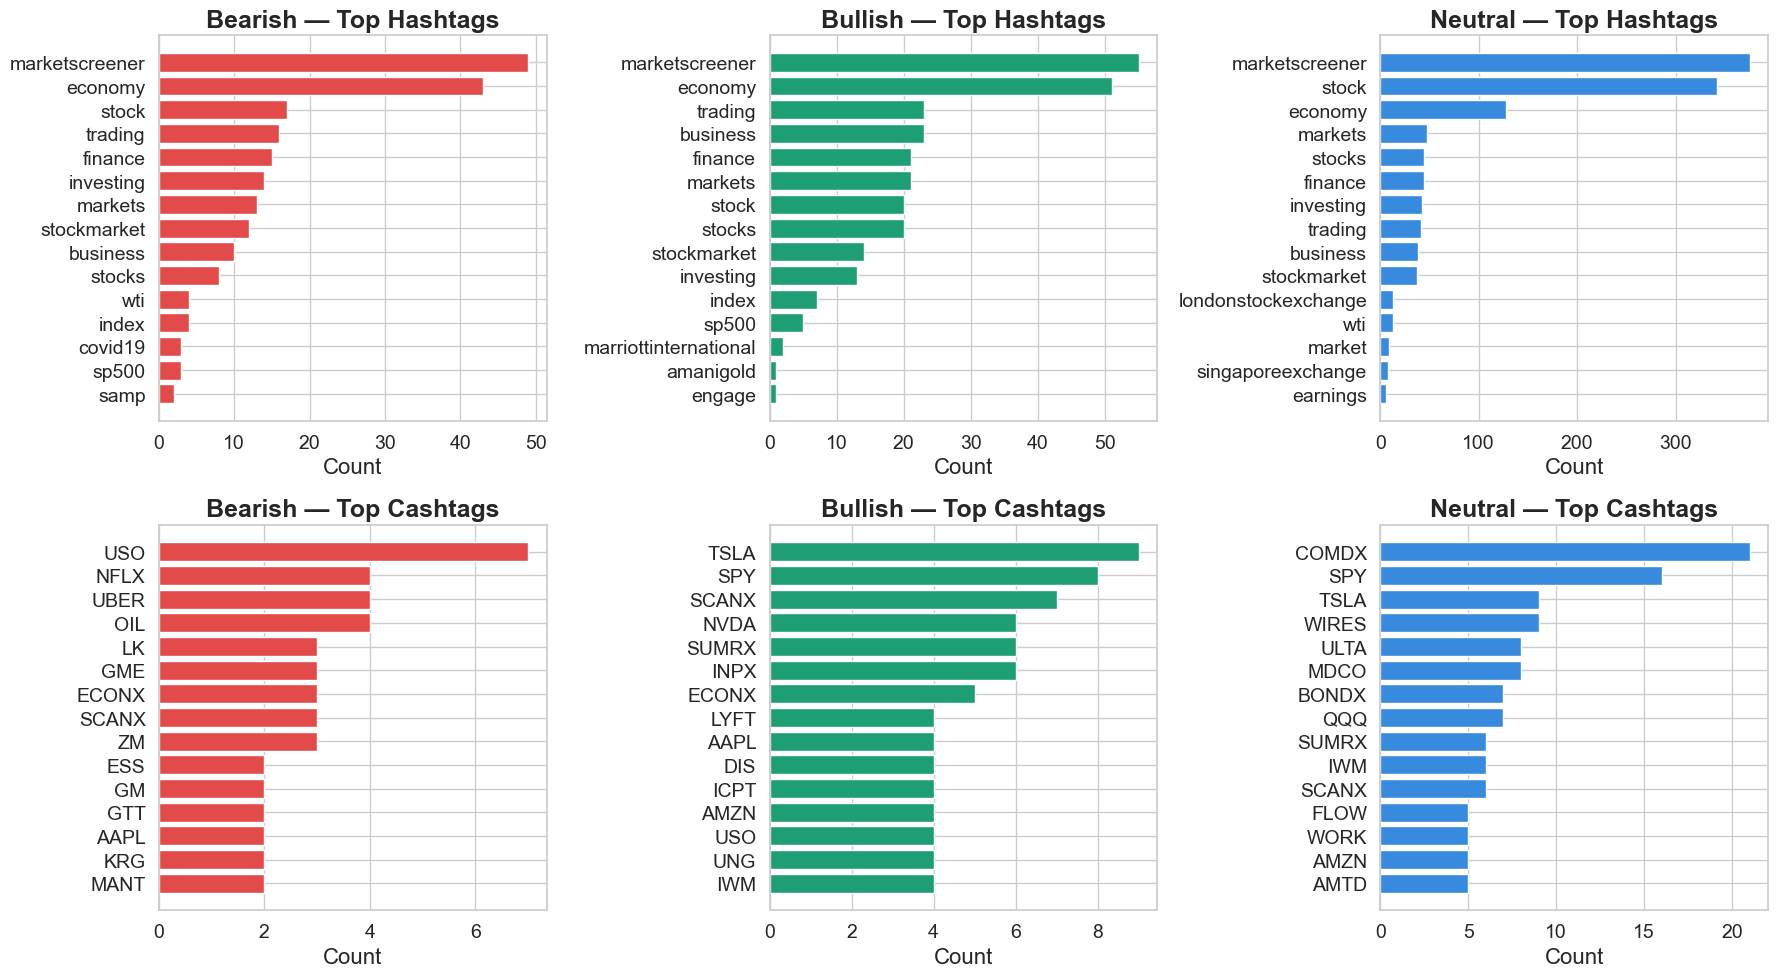

In [30]:
train['hashtags']   = train['text'].apply(lambda t: re.findall(r'#(\w+)', t.lower()))
train['mentions']   = train['text'].apply(lambda t: re.findall(r'@(\w+)', t.lower()))
train['n_hashtags'] = train['hashtags'].str.len()
train['n_mentions'] = train['mentions'].str.len()
train['has_url']    = train['text'].str.contains(r'https?://\S+|www\.\S+', regex=True)
train['has_cashtag']= train['text'].str.contains(r'\$[A-Z]{2,5}', regex=True)

TOP_N = 15

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, label_id in enumerate(sorted(LABEL_MAP)):
    subset = train[train['label'] == label_id]

    # ----- HASHTAGS -----
    hashtags = [h for hs in subset['hashtags'] for h in hs]
    if hashtags:
        words, freqs = zip(*Counter(hashtags).most_common(TOP_N))
        axes[0, i].barh(list(words)[::-1], list(freqs)[::-1],
                        color=PALETTE[label_id], edgecolor='white')
        axes[0, i].set_title(f'{LABEL_MAP[label_id]} — Top Hashtags', fontweight='bold')
        axes[0, i].set_xlabel('Count')

    # ----- CASHTAGS -----
    cashtags = re.findall(r'\$([A-Z]{2,5})', ' '.join(subset['text'].tolist()))
    if cashtags:
        words, freqs = zip(*Counter(cashtags).most_common(TOP_N))
        axes[1, i].barh(list(words)[::-1], list(freqs)[::-1],
                        color=PALETTE[label_id], edgecolor='white')
        axes[1, i].set_title(f'{LABEL_MAP[label_id]} — Top Cashtags', fontweight='bold')
        axes[1, i].set_xlabel('Count')

plt.tight_layout()
plt.savefig('top_hashtags_cashtags_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print('EXPLORATION SUMMARY\n')

for label, group in train.groupby('label_name'):
    print(f'{label.upper()}')
    print(f'Avg chars  : {group["char_count"].mean():.0f}')
    print(f'Avg words  : {group["word_count"].mean():.0f}')
    print(f'Has URL    : {group["has_url"].mean()*100:.1f}%')
    print(f'Has cashtag: {group["has_cashtag"].mean()*100:.1f}%\n')

EXPLORATION SUMMARY

BEARISH
Avg chars  : 83
Avg words  : 12
Has URL    : 44.3%
Has cashtag: 13.7%

BULLISH
Avg chars  : 80
Avg words  : 12
Has URL    : 39.1%
Has cashtag: 24.6%

NEUTRAL
Avg chars  : 88
Avg words  : 12
Has URL    : 49.8%
Has cashtag: 12.0%



<a class="anchor" id="3">

## **3. Corpus Split**

[Back to TOC](#toc)
</a>

Corpus split is a crucial step no only in machine learning pipelines but also in NLP pipelines as it allows us to evaluate our models on unseen data and prevent overfitting. In this section, we will split our training data into a training set and a validation set.